# Push-Up Posture Checker Dev
This notebook is used for development of the posture-checking pipeline
(rule-based + ML prototype).

The final comparison across MediaPipe/MMPose and 2D/3D, as well as the
final exported MLP models, are handled in notebook 04.

In [1]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
from pathlib import Path

# Project root (notebook inside /notebooks)
PROJECT_ROOT = Path.cwd().parent

# Processed data directory
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Input feature files
FEATURES_2D_PATH = PROCESSED_DIR / "mmpose_2d_features_video_level.csv"
FEATURES_3D_PATH = PROCESSED_DIR / "mmpose_3d_features_video_level.csv"

# Debug
print("Processed dir:", PROCESSED_DIR)
print("2D features:", FEATURES_2D_PATH)
print("3D features:", FEATURES_3D_PATH)

df_2d = pd.read_csv(FEATURES_2D_PATH)
df_3d = pd.read_csv(FEATURES_3D_PATH)

print("2D shape:", df_2d.shape)
print("3D shape:", df_3d.shape)

display(df_2d.head())
display(df_3d.head())

Processed dir: C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker\data\processed
2D features: C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker\data\processed\mmpose_2d_features_video_level.csv
3D features: C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker\data\processed\mmpose_3d_features_video_level.csv
2D shape: (100, 7)
3D shape: (100, 7)


,video,label,n_frames,elbow_angle_mean,elbow_angle_std,body_alignment_angle_mean,hip_angle_mean
0,1,incorrect,290,0.606726,0.325572,0.503093,0.561281
1,10,incorrect,126,0.808515,0.304271,0.540342,0.583426
2,11,incorrect,83,0.843668,0.172181,0.433966,0.586137
3,12,incorrect,121,0.863101,0.228995,0.435333,0.507447
4,13,incorrect,121,0.767248,0.291847,0.488523,0.644316


,video,label,n_frames,elbow_angle_mean,elbow_angle_std,body_alignment_angle_mean,hip_angle_mean
0,1,incorrect,290,0.479673,0.289068,0.240745,0.449607
1,10,incorrect,126,0.281403,0.267537,0.257299,0.326346
2,11,incorrect,83,0.547342,0.311713,0.154850,0.418216
3,12,incorrect,121,0.449366,0.257979,0.191540,0.322883
4,13,incorrect,121,0.440645,0.236045,0.169475,0.455429


In [3]:
def encode_labels(df):
    df = df.copy()
    df["label_num"] = df["label"].map({"correct": 1, "incorrect": 0})
    return df

df_2d = encode_labels(df_2d)
df_3d = encode_labels(df_3d)

print(df_2d["label_num"].value_counts())
print(df_3d["label_num"].value_counts())

label_num
0    50
1    50
Name: count, dtype: int64
label_num
0    50
1    50
Name: count, dtype: int64


In [4]:
features_to_check = [
    "elbow_angle_mean",
    "elbow_angle_std",
    "body_alignment_angle_mean",
    "hip_angle_mean"
]

print("2D grouped by label")
display(df_2d.groupby("label")[features_to_check].describe())

print("\n3D grouped by label")
display(df_3d.groupby("label")[features_to_check].describe())

2D grouped by label


elbow_angle_mean                                                    \
                     count      mean       std       min       25%       50%   
label                                                                          
correct               50.0  0.638916  0.061103  0.511657  0.601600  0.629684   
incorrect             50.0  0.662571  0.107354  0.448900  0.581409  0.656184   

                             elbow_angle_std            ...  \
                75%      max           count      mean  ...   
label                                                   ...   
correct    0.656292  0.81025            50.0  0.363508  ...   
incorrect  0.716077  0.91080            50.0  0.327805  ...   

          body_alignment_angle_mean           hip_angle_mean            \
                                75%       max          count      mean   
label                                                                    
correct                    0.646313  0.737368           50.0  0.511312   
incorrect                  0.591219  0.788658           50.0  0.533369   

                                                                       
                std       min       25%       50%       75%       max  
label                                                                  
correct    0.100510  0.323852  0.442558  0.502132  0.583693  0.731772  
incorrect  0.107114  0.277855  0.480630  0.527364  0.626955  0.724046  

[2 rows x 32 columns]


3D grouped by label


elbow_angle_mean                                                    \
                     count      mean       std       min       25%       50%   
label                                                                          
correct               50.0  0.571607  0.092449  0.287223  0.499249  0.581517   
incorrect             50.0  0.499735  0.107006  0.281403  0.413094  0.504278   

                              elbow_angle_std            ...  \
                75%       max           count      mean  ...   
label                                                    ...   
correct    0.627010  0.733948            50.0  0.346229  ...   
incorrect  0.576267  0.737933            50.0  0.294469  ...   

          body_alignment_angle_mean           hip_angle_mean            \
                                75%       max          count      mean   
label                                                                    
correct                    0.414137  0.495476           50.0  0.292176   
incorrect                  0.357501  0.504870           50.0  0.364881   

                                                                       
                std       min       25%       50%       75%       max  
label                                                                  
correct    0.060547  0.182701  0.247792  0.287390  0.331165  0.440926  
incorrect  0.084258  0.105392  0.325147  0.370739  0.417912  0.526810  

[2 rows x 32 columns]

In [5]:
def rule_based_classifier(df, mode="2d"):
    """
    Data-driven rule-based classifier adapted to MMPose features.

    mode:
        - "2d": uses elbow_std + body alignment
        - "3d": uses elbow_mean + elbow_std

    Returns:
        numpy array (1 = correct, 0 = incorrect)
    """

    preds = []

    for _, row in df.iterrows():

        elbow_mean = row["elbow_angle_mean"]
        elbow_std = row["elbow_angle_std"]
        body = row["body_alignment_angle_mean"]

        if mode == "2d":
            is_correct = (
                (elbow_std > 0.34) and
                (body > 0.53)
            )

        elif mode == "3d":
            is_correct = (
                (elbow_mean > 0.53) and
                (elbow_std > 0.31)
            )

        else:
            raise ValueError("mode must be '2d' or '3d'")

        preds.append(1 if is_correct else 0)

    return np.array(preds)

In [10]:
y_2d = df_2d["label"]
y_3d = df_3d["label"]

rb_pred_2d = rule_based_classifier(df_2d, mode="2d")
rb_pred_3d = rule_based_classifier(df_3d, mode="3d")

label_map = {0: "incorrect", 1: "correct"}

rb_pred_2d = pd.Series(rb_pred_2d).map(label_map)
rb_pred_3d = pd.Series(rb_pred_3d).map(label_map)

print("Rule-based 2D accuracy:", accuracy_score(y_2d, rb_pred_2d))
print("Rule-based 3D accuracy:", accuracy_score(y_3d, rb_pred_3d))

Rule-based 2D accuracy: 0.67
Rule-based 3D accuracy: 0.67


In [12]:
y_2d = df_2d["label"]
y_3d = df_3d["label"]

rb_pred_2d = rule_based_classifier(df_2d, mode="2d")
rb_pred_3d = rule_based_classifier(df_3d, mode="3d")

label_map = {0: "incorrect", 1: "correct"}
rb_pred_2d = pd.Series(rb_pred_2d).map(label_map)
rb_pred_3d = pd.Series(rb_pred_3d).map(label_map)

print("Rule-based 2D accuracy:", accuracy_score(y_2d, rb_pred_2d))
print("Rule-based 3D accuracy:", accuracy_score(y_3d, rb_pred_3d))

print("\n2D counts:")
print(rb_pred_2d.value_counts())

print("\n3D counts:")
print(rb_pred_3d.value_counts())

Rule-based 2D accuracy: 0.67
Rule-based 3D accuracy: 0.67

2D counts:
incorrect    67
correct      33
Name: count, dtype: int64

3D counts:
incorrect    67
correct      33
Name: count, dtype: int64


In [13]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [14]:
FEATURES = [
    "elbow_angle_mean",
    "elbow_angle_std",
    "body_alignment_angle_mean",
    "hip_angle_mean",
]

X_2d = df_2d[FEATURES]
y_2d = df_2d["label_num"]

X_3d = df_3d[FEATURES]
y_3d = df_3d["label_num"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d
)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X_3d, y_3d, test_size=0.2, random_state=42, stratify=y_3d
)

print("2D train shape:", X2_train.shape)
print("2D test shape:", X2_test.shape)
print("3D train shape:", X3_train.shape)
print("3D test shape:", X3_test.shape)

2D train shape: (80, 4)
2D test shape: (20, 4)
3D train shape: (80, 4)
3D test shape: (20, 4)


In [15]:
rb_pred_2d = rule_based_classifier(df_2d, mode="2d")
rb_pred_3d = rule_based_classifier(df_3d, mode="3d")

rule_acc_2d = accuracy_score(y_2d, rb_pred_2d)
rule_acc_3d = accuracy_score(y_3d, rb_pred_3d)

print("Rule-based 2D accuracy:", rule_acc_2d)
print("Rule-based 3D accuracy:", rule_acc_3d)

print("\nRule-based 2D classification report:")
print(classification_report(y_2d, rb_pred_2d, target_names=["incorrect", "correct"]))

print("\nRule-based 3D classification report:")
print(classification_report(y_3d, rb_pred_3d, target_names=["incorrect", "correct"]))

Rule-based 2D accuracy: 0.67
Rule-based 3D accuracy: 0.67

Rule-based 2D classification report:
              precision    recall  f1-score   support

   incorrect       0.63      0.84      0.72        50
     correct       0.76      0.50      0.60        50

    accuracy                           0.67       100
   macro avg       0.69      0.67      0.66       100
weighted avg       0.69      0.67      0.66       100


Rule-based 3D classification report:
              precision    recall  f1-score   support

   incorrect       0.63      0.84      0.72        50
     correct       0.76      0.50      0.60        50

    accuracy                           0.67       100
   macro avg       0.69      0.67      0.66       100
weighted avg       0.69      0.67      0.66       100



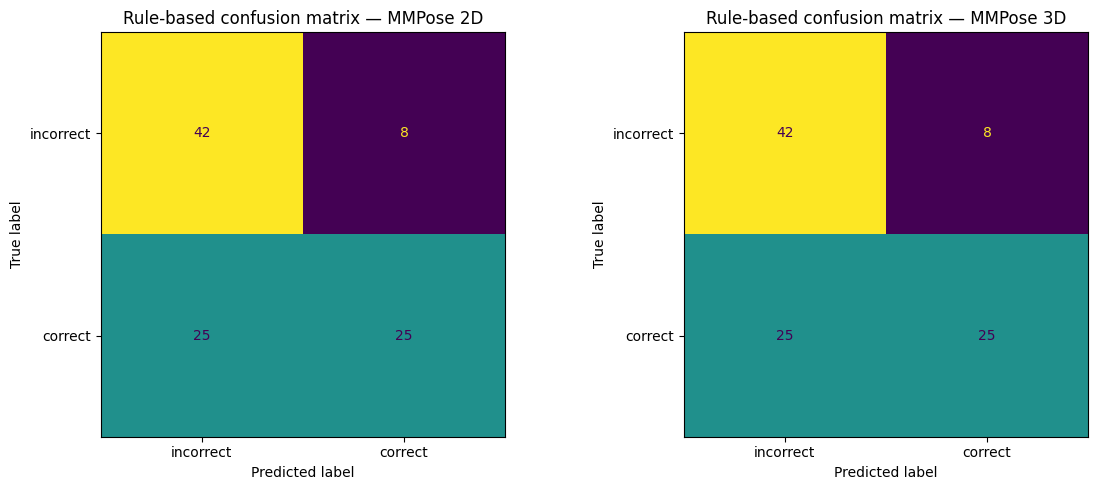

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_2d = confusion_matrix(y_2d, rb_pred_2d)
disp_2d = ConfusionMatrixDisplay(confusion_matrix=cm_2d, display_labels=["incorrect", "correct"])
disp_2d.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Rule-based confusion matrix — MMPose 2D")

cm_3d = confusion_matrix(y_3d, rb_pred_3d)
disp_3d = ConfusionMatrixDisplay(confusion_matrix=cm_3d, display_labels=["incorrect", "correct"])
disp_3d.plot(ax=axes[1], colorbar=False)
axes[1].set_title("Rule-based confusion matrix — MMPose 3D")

plt.tight_layout()
plt.show()

In [17]:
mlp_pipeline_2d = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        max_iter=1000,
        random_state=42
    ))
])

mlp_pipeline_3d = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        max_iter=1000,
        random_state=42
    ))
])

In [18]:
mlp_pipeline_2d.fit(X2_train, y2_train)
mlp_pred_2d = mlp_pipeline_2d.predict(X2_test)
mlp_test_acc_2d = accuracy_score(y2_test, mlp_pred_2d)

mlp_pipeline_3d.fit(X3_train, y3_train)
mlp_pred_3d = mlp_pipeline_3d.predict(X3_test)
mlp_test_acc_3d = accuracy_score(y3_test, mlp_pred_3d)

print("MLP 2D test accuracy:", mlp_test_acc_2d)
print("MLP 3D test accuracy:", mlp_test_acc_3d)

print("\nMLP 2D classification report:")
print(classification_report(y2_test, mlp_pred_2d, target_names=["incorrect", "correct"]))

print("\nMLP 3D classification report:")
print(classification_report(y3_test, mlp_pred_3d, target_names=["incorrect", "correct"]))

MLP 2D test accuracy: 0.6
MLP 3D test accuracy: 0.7

MLP 2D classification report:
              precision    recall  f1-score   support

   incorrect       0.60      0.60      0.60        10
     correct       0.60      0.60      0.60        10

    accuracy                           0.60        20
   macro avg       0.60      0.60      0.60        20
weighted avg       0.60      0.60      0.60        20


MLP 3D classification report:
              precision    recall  f1-score   support

   incorrect       0.67      0.80      0.73        10
     correct       0.75      0.60      0.67        10

    accuracy                           0.70        20
   macro avg       0.71      0.70      0.70        20
weighted avg       0.71      0.70      0.70        20



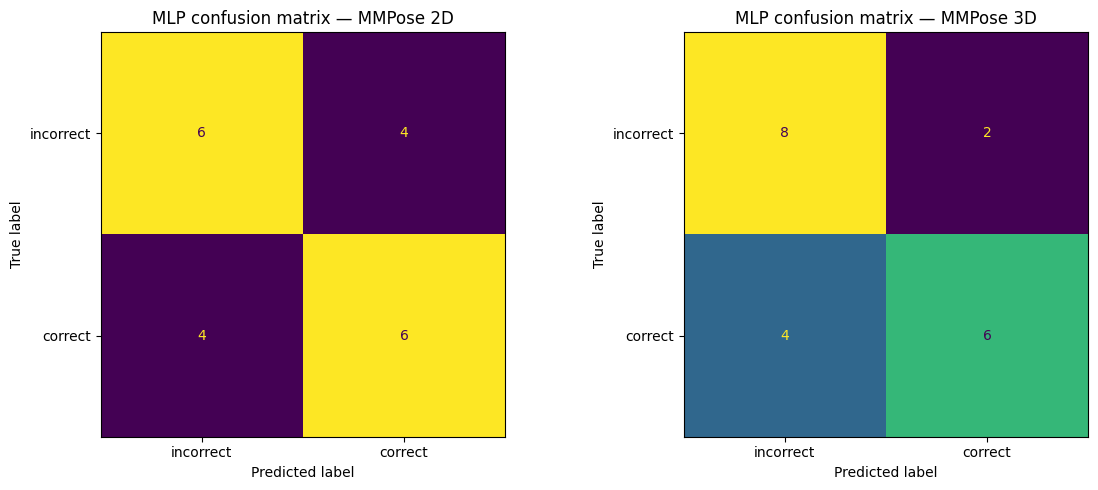

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_mlp_2d = confusion_matrix(y2_test, mlp_pred_2d)
disp_mlp_2d = ConfusionMatrixDisplay(confusion_matrix=cm_mlp_2d, display_labels=["incorrect", "correct"])
disp_mlp_2d.plot(ax=axes[0], colorbar=False)
axes[0].set_title("MLP confusion matrix — MMPose 2D")

cm_mlp_3d = confusion_matrix(y3_test, mlp_pred_3d)
disp_mlp_3d = ConfusionMatrixDisplay(confusion_matrix=cm_mlp_3d, display_labels=["incorrect", "correct"])
disp_mlp_3d.plot(ax=axes[1], colorbar=False)
axes[1].set_title("MLP confusion matrix — MMPose 3D")

plt.tight_layout()
plt.show()

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_2d = cross_val_score(
    mlp_pipeline_2d,
    X_2d,
    y_2d,
    cv=cv,
    scoring="accuracy"
)

cv_scores_3d = cross_val_score(
    mlp_pipeline_3d,
    X_3d,
    y_3d,
    cv=cv,
    scoring="accuracy"
)

print("MLP 2D CV scores:", cv_scores_2d)
print("MLP 2D CV mean:", cv_scores_2d.mean())

print("\nMLP 3D CV scores:", cv_scores_3d)
print("MLP 3D CV mean:", cv_scores_3d.mean())

MLP 2D CV scores: [0.6  0.6  0.7  0.75 0.6 ]
MLP 2D CV mean: 0.65

MLP 3D CV scores: [0.9  0.85 0.75 0.8  0.7 ]
MLP 3D CV mean: 0.8


In [21]:
comparison_2d = pd.DataFrame({
    "Method": ["Rule-based", "MLP (test split)", "MLP (5-fold CV mean)"],
    "Accuracy": [
        rule_acc_2d,
        mlp_test_acc_2d,
        cv_scores_2d.mean()
    ]
})

comparison_3d = pd.DataFrame({
    "Method": ["Rule-based", "MLP (test split)", "MLP (5-fold CV mean)"],
    "Accuracy": [
        rule_acc_3d,
        mlp_test_acc_3d,
        cv_scores_3d.mean()
    ]
})

print("MMPose 2D results")
display(comparison_2d)

print("MMPose 3D results")
display(comparison_3d)

MMPose 2D results


,Method,Accuracy
0,Rule-based,0.67
1,MLP (test split),0.60
2,MLP (5-fold CV mean),0.65


MMPose 3D results


,Method,Accuracy
0,Rule-based,0.67
1,MLP (test split),0.70
2,MLP (5-fold CV mean),0.80


In [22]:
summary_df = pd.DataFrame({
    "Method": ["Rule-based", "MLP (test split)", "MLP (5-fold CV mean)"],
    "MMPose 2D": [
        rule_acc_2d,
        mlp_test_acc_2d,
        cv_scores_2d.mean()
    ],
    "MMPose 3D": [
        rule_acc_3d,
        mlp_test_acc_3d,
        cv_scores_3d.mean()
    ]
})

display(summary_df)

,Method,MMPose 2D,MMPose 3D
0,Rule-based,0.67,0.67
1,MLP (test split),0.60,0.70
2,MLP (5-fold CV mean),0.65,0.80


## Baseline & Comparison

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score

In [24]:
logreg_pipeline_2d = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipeline_3d = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipeline_2d.fit(X2_train, y2_train)
logreg_pipeline_3d.fit(X3_train, y3_train)

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [25]:
y2_pred_logreg = logreg_pipeline_2d.predict(X2_test)
y3_pred_logreg = logreg_pipeline_3d.predict(X3_test)

logreg_test_acc_2d = accuracy_score(y2_test, y2_pred_logreg)
logreg_test_acc_3d = accuracy_score(y3_test, y3_pred_logreg)

logreg_bal_acc_2d = balanced_accuracy_score(y2_test, y2_pred_logreg)
logreg_bal_acc_3d = balanced_accuracy_score(y3_test, y3_pred_logreg)

logreg_precision_2d = precision_score(y2_test, y2_pred_logreg, average="weighted", zero_division=0)
logreg_precision_3d = precision_score(y3_test, y3_pred_logreg, average="weighted", zero_division=0)

logreg_recall_2d = recall_score(y2_test, y2_pred_logreg, average="weighted", zero_division=0)
logreg_recall_3d = recall_score(y3_test, y3_pred_logreg, average="weighted", zero_division=0)

logreg_f1_2d = f1_score(y2_test, y2_pred_logreg, average="weighted", zero_division=0)
logreg_f1_3d = f1_score(y3_test, y3_pred_logreg, average="weighted", zero_division=0)

print("LogReg 2D accuracy:", round(logreg_test_acc_2d, 4))
print("LogReg 3D accuracy:", round(logreg_test_acc_3d, 4))

LogReg 2D accuracy: 0.55
LogReg 3D accuracy: 0.75


In [26]:
cv_scores_logreg_2d = cross_val_score(
    logreg_pipeline_2d,
    X_2d,
    y_2d,
    cv=cv,
    scoring="accuracy"
)

cv_scores_logreg_3d = cross_val_score(
    logreg_pipeline_3d,
    X_3d,
    y_3d,
    cv=cv,
    scoring="accuracy"
)

print("LogReg 2D CV mean:", round(cv_scores_logreg_2d.mean(), 4))
print("LogReg 3D CV mean:", round(cv_scores_logreg_3d.mean(), 4))

LogReg 2D CV mean: 0.69
LogReg 3D CV mean: 0.75


In [29]:
# MLP predictions on the test sets
y2_pred = mlp_pipeline_2d.predict(X2_test)
y3_pred = mlp_pipeline_3d.predict(X3_test)

# MLP test accuracies
mlp_test_acc_2d = accuracy_score(y2_test, y2_pred)
mlp_test_acc_3d = accuracy_score(y3_test, y3_pred)

print("MLP 2D accuracy:", round(mlp_test_acc_2d, 4))
print("MLP 3D accuracy:", round(mlp_test_acc_3d, 4))

MLP 2D accuracy: 0.6
MLP 3D accuracy: 0.7


In [31]:
# Ensure prediction variable names are consistent
try:
    y2_pred
except NameError:
    try:
        y2_pred = y2_pred_2d
    except NameError:
        raise ValueError("MLP 2D predictions not found")

try:
    y3_pred
except NameError:
    try:
        y3_pred = y3_pred_3d
    except NameError:
        raise ValueError("MLP 3D predictions not found")

In [32]:
# MLP metrics
mlp_bal_acc_2d = balanced_accuracy_score(y2_test, y2_pred)
mlp_bal_acc_3d = balanced_accuracy_score(y3_test, y3_pred)

mlp_precision_2d = precision_score(y2_test, y2_pred, average="weighted", zero_division=0)
mlp_precision_3d = precision_score(y3_test, y3_pred, average="weighted", zero_division=0)

mlp_recall_2d = recall_score(y2_test, y2_pred, average="weighted", zero_division=0)
mlp_recall_3d = recall_score(y3_test, y3_pred, average="weighted", zero_division=0)

mlp_f1_2d = f1_score(y2_test, y2_pred, average="weighted", zero_division=0)
mlp_f1_3d = f1_score(y3_test, y3_pred, average="weighted", zero_division=0)

# Rule-based metrics
rule_bal_acc_2d = balanced_accuracy_score(y_2d, rb_pred_2d)
rule_bal_acc_3d = balanced_accuracy_score(y_3d, rb_pred_3d)

rule_precision_2d = precision_score(y_2d, rb_pred_2d, average="weighted", zero_division=0)
rule_precision_3d = precision_score(y_3d, rb_pred_3d, average="weighted", zero_division=0)

rule_recall_2d = recall_score(y_2d, rb_pred_2d, average="weighted", zero_division=0)
rule_recall_3d = recall_score(y_3d, rb_pred_3d, average="weighted", zero_division=0)

rule_f1_2d = f1_score(y_2d, rb_pred_2d, average="weighted", zero_division=0)
rule_f1_3d = f1_score(y_3d, rb_pred_3d, average="weighted", zero_division=0)

In [33]:
comparison_2d = pd.DataFrame([
    {
        "Method": "Rule-based",
        "Accuracy": accuracy_score(y_2d, rb_pred_2d),
        "Balanced Accuracy": rule_bal_acc_2d,
        "F1": rule_f1_2d
    },
    {
        "Method": "LogReg",
        "Accuracy": logreg_test_acc_2d,
        "Balanced Accuracy": logreg_bal_acc_2d,
        "F1": logreg_f1_2d
    },
    {
        "Method": "MLP",
        "Accuracy": mlp_test_acc_2d,
        "Balanced Accuracy": mlp_bal_acc_2d,
        "F1": mlp_f1_2d
    }
])

display(comparison_2d.round(4))

,Method,Accuracy,Balanced Accuracy,F1
0,Rule-based,0.67,0.67,0.6602
1,LogReg,0.55,0.55,0.5489
2,MLP,0.60,0.60,0.6000


In [34]:
comparison_3d = pd.DataFrame([
    {
        "Method": "Rule-based",
        "Accuracy": accuracy_score(y_3d, rb_pred_3d),
        "Balanced Accuracy": rule_bal_acc_3d,
        "F1": rule_f1_3d
    },
    {
        "Method": "LogReg",
        "Accuracy": logreg_test_acc_3d,
        "Balanced Accuracy": logreg_bal_acc_3d,
        "F1": logreg_f1_3d
    },
    {
        "Method": "MLP",
        "Accuracy": mlp_test_acc_3d,
        "Balanced Accuracy": mlp_bal_acc_3d,
        "F1": mlp_f1_3d
    }
])

display(comparison_3d.round(4))

,Method,Accuracy,Balanced Accuracy,F1
0,Rule-based,0.67,0.67,0.6602
1,LogReg,0.75,0.75,0.7494
2,MLP,0.70,0.70,0.6970
